# Numbeo Cost of Living: Data Exploration (Country Level)

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

## 1. Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

In [4]:
def load_numbeo_file(filepath):
    all_years = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        try:
            df = pd.read_excel(filepath, sheet_name=sheet)
            df['year'] = int(str(sheet).strip())
            all_years.append(df)
            print(f'✓ Loaded sheet: {sheet} — {len(df)} rows')
        except Exception as e:
            print(f'✗ Skipped sheet: {sheet} — {e}')
    return pd.concat(all_years, ignore_index=True)

df = load_numbeo_file('../data/raw/numbeo_cost_of_living_country.xlsx')

✓ Loaded sheet: 2016 — 122 rows
✓ Loaded sheet: 2017 — 121 rows
✓ Loaded sheet: 2018 — 115 rows
✓ Loaded sheet: 2019 — 119 rows
✓ Loaded sheet: 2020 — 132 rows
✓ Loaded sheet: 2021 — 138 rows
✓ Loaded sheet: 2022 — 139 rows
✓ Loaded sheet: 2023 — 140 rows
✓ Loaded sheet: 2024 — 146 rows
✓ Loaded sheet: 2025 — 139 rows


## 2. Observation Units and Variables of Interest

**Observation unit:** Country-year combination

**Variables of interest:**
- `Cost of Living Index` — overall cost of living relative to New York City (100)
- `Rent Index` — rent costs relative to New York City
- `Groceries Index` — grocery prices relative to New York City
- `Restaurant Price Index` — restaurant prices relative to New York City
- `Local Purchasing Power Index` — relative purchasing power of average local salary

**Important note on the index:** All values are relative to New York City = 100. This means cross-sectional comparisons between countries within a single year are valid and meaningful. However, tracking a single country's index value over time is not a valid measure of absolute cost change, since New York's own prices shift each year while always being anchored at 100. Rank-based comparisons over time are used instead.

In [5]:
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Total unique countries: {df["Country"].nunique()}')
df.head(10)

Shape: (1311, 9)
Columns: ['Rank', 'Country', 'Cost of Living Index', 'Rent Index', 'Cost of Living Plus Rent Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'year']
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Total unique countries: 152


,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,year
0,1,Bermuda,133.7,120.1,127.2,131.9,121.3,118.5,2016
1,2,Switzerland,123.1,55.1,90.4,123.9,119.1,178.7,2016
2,3,Bahamas,107.5,38.2,74.2,107.1,88.4,59.0,2016
3,4,Norway,99.8,37.0,69.6,93.3,110.8,125.8,2016
4,5,Iceland,96.5,35.4,67.1,91.4,98.8,94.0,2016
5,6,Denmark,84.9,30.8,58.9,69.2,97.9,142.1,2016
6,7,Singapore,83.7,73.9,79.0,75.8,53.8,110.5,2016
7,8,Luxembourg,82.0,48.9,66.1,69.2,90.3,154.4,2016
8,9,Kuwait,81.6,38.3,60.8,96.1,46.0,113.6,2016
9,10,Hong Kong,81.5,82.6,82.0,88.8,50.7,102.3,2016


## 3. Locating and Handling Missing Data

In [6]:
# Missing data per column
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nMissing % per column:')
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
Rank                              0
Country                           0
Cost of Living Index              0
Rent Index                        0
Cost of Living Plus Rent Index    0
Groceries Index                   0
Restaurant Price Index            0
Local Purchasing Power Index      0
year                              0
dtype: int64

Missing % per column:
Rank                              0.0
Country                           0.0
Cost of Living Index              0.0
Rent Index                        0.0
Cost of Living Plus Rent Index    0.0
Groceries Index                   0.0
Restaurant Price Index            0.0
Local Purchasing Power Index      0.0
year                              0.0
dtype: float64


In [7]:
# How many countries per year?
print('Countries per year:')
print(df.groupby('year').size().to_string())

Countries per year:
year
2016    122
2017    121
2018    115
2019    119
2020    132
2021    138
2022    139
2023    140
2024    146
2025    139


In [8]:
# Which countries appear in all years?
year_count = df.groupby('Country')['year'].nunique()
all_years_countries = year_count[year_count == df['year'].nunique()].index.tolist()
print(f'Countries present in all {df["year"].nunique()} years: {len(all_years_countries)}')
print(all_years_countries)

Countries present in all 10 years: 106
['Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Bolivia', 'Bosnia And Herzegovina', 'Brazil', 'Bulgaria', 'Cambodia', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Montenegro', 'Morocco', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Palestine', 'Panama', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Romania', 'Russ

## 4. Transforming and Adding New Variables

In [9]:
# Add rank within each year for cross-year rank comparison
# Rank 1 = most expensive
df['cost_rank'] = df.groupby('year')['Cost of Living Index'].rank(ascending=False).astype(int)

print('Sample with rank added:')
print(df[df['year'] == 2025][['Country', 'Cost of Living Index', 'cost_rank']].sort_values('cost_rank').head(10).to_string(index=False))

Sample with rank added:
          Country  Cost of Living Index  cost_rank
Us Virgin Islands                  98.4          1
      Switzerland                  98.4          1
          Iceland                  83.4          3
          Bahamas                  81.4          4
        Singapore                  79.1          5
Hong Kong (China)                  73.6          6
         Barbados                  70.0          7
           Norway                  69.0          8
 Papua New Guinea                  67.4          9
          Denmark                  66.9         10


## 5. Creating and Saving Clean Subsets

In [10]:
# Save full clean dataset
df.to_csv('../data/clean/numbeo_cost_of_living_country_clean.csv', index=False)
print(f'Saved numbeo_cost_of_living_country_clean.csv — {df.shape[0]} rows')

# Save consistent countries only (appear in all years) for rank change analysis
df_consistent = df[df['Country'].isin(all_years_countries)]
df_consistent.to_csv('../data/clean/numbeo_cost_of_living_country_consistent.csv', index=False)
print(f'Saved numbeo_cost_of_living_country_consistent.csv — {df_consistent.shape[0]} rows, {len(all_years_countries)} countries')

# Save latest year only for cross-sectional analysis
df_latest = df[df['year'] == df['year'].max()]
df_latest.to_csv('../data/clean/numbeo_cost_of_living_country_2025.csv', index=False)
print(f'Saved numbeo_cost_of_living_country_2025.csv — {df_latest.shape[0]} rows')

Saved numbeo_cost_of_living_country_clean.csv — 1311 rows
Saved numbeo_cost_of_living_country_consistent.csv — 1060 rows, 106 countries
Saved numbeo_cost_of_living_country_2025.csv — 139 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2016 to 2025, annual
- **Spatial:** Approximately 100 to 130 countries globally depending on year
- **Key limitation:** All indices are relative to New York City = 100. Cross-sectional comparisons within a single year are valid. Rank-based comparisons over time are valid. Absolute cost change over time cannot be measured with this data.

In [11]:
# Countries covered in 2025
print(f'Countries in 2025: {df[df["year"] == 2025]["Country"].nunique()}')
print(f'\nAll countries in 2025:')
print(df[df['year'] == 2025]['Country'].sort_values().tolist())

Countries in 2025: 139

All countries in 2025:
['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bolivia', 'Bosnia And Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guernsey', 'Honduras', 'Hong Kong (China)', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo (Disputed Territory)', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Luxembourg', 'Macao (China)', 'Madagascar', 'Malaysia', 'Maldives', 'Malta', 'Mauritius', '

## 7. Key Questions Relating to the Research Questions

1. Which countries have the highest and lowest cost of living in 2025?
2. Which countries are most expensive for rent specifically — and does this differ from overall cost of living?
3. Which countries offer the highest purchasing power relative to their cost of living?
4. Have country rankings shifted since COVID — which countries became relatively more or less expensive compared to others?
5. Is there a cluster of middle-income countries that are cheap but have decent purchasing power — the potential sweet spot candidates?

## 8. Descriptive Analysis

In [12]:
# 8.1 Most and least expensive countries in 2025
latest = df[df['year'] == df['year'].max()]

print('Top 10 most expensive countries (2025):')
print(latest[['Country', 'Cost of Living Index']].sort_values('Cost of Living Index', ascending=False).head(10).to_string(index=False))

print('\nTop 10 cheapest countries (2025):')
print(latest[['Country', 'Cost of Living Index']].sort_values('Cost of Living Index').head(10).to_string(index=False))

Top 10 most expensive countries (2025):
          Country  Cost of Living Index
Us Virgin Islands                  98.4
      Switzerland                  98.4
          Iceland                  83.4
          Bahamas                  81.4
        Singapore                  79.1
Hong Kong (China)                  73.6
         Barbados                  70.0
           Norway                  69.0
 Papua New Guinea                  67.4
          Denmark                  66.9

Top 10 cheapest countries (2025):
    Country  Cost of Living Index
   Pakistan                  17.8
      Libya                  18.6
      Egypt                  19.0
      India                  19.5
Afghanistan                  19.9
 Madagascar                  20.7
 Bangladesh                  20.9
     Russia                  22.3
      Nepal                  23.0
   Paraguay                  23.0


In [13]:
# 8.2 Top 10 most expensive by each category in 2025
categories = {
    'Cost of Living Index':   'Top 10 Highest Cost of Living (2025)',
    'Rent Index':             'Top 10 Highest Rent (2025)',
    'Groceries Index':        'Top 10 Most Expensive Groceries (2025)',
    'Restaurant Price Index': 'Top 10 Most Expensive Restaurants (2025)',
}

for col, title in categories.items():
    print(f'\n========== {title} ==========')
    print(latest[['Country', col]].sort_values(col, ascending=False).head(10).to_string(index=False))


========== Top 10 Highest Cost of Living (2025) ==========
          Country  Cost of Living Index
Us Virgin Islands                  98.4
      Switzerland                  98.4
          Iceland                  83.4
          Bahamas                  81.4
        Singapore                  79.1
Hong Kong (China)                  73.6
         Barbados                  70.0
           Norway                  69.0
 Papua New Guinea                  67.4
          Denmark                  66.9

========== Top 10 Highest Rent (2025) ==========
             Country  Rent Index
           Singapore        67.0
   Hong Kong (China)        55.7
             Bahamas        46.9
   Us Virgin Islands        46.4
            Guernsey        45.7
         Switzerland        45.2
             Iceland        43.7
          Luxembourg        42.2
       United States        40.9
United Arab Emirates        39.7

========== Top 10 Most Expensive Groceries (2025) ==========
          Country  Grocer

In [14]:
# 8.3 Top 10 cheapest by each category in 2025
for col, title in categories.items():
    print(f'\n========== Cheapest: {col} (2025) ==========')
    print(latest[['Country', col]].sort_values(col).head(10).to_string(index=False))


========== Cheapest: Cost of Living Index (2025) ==========
    Country  Cost of Living Index
   Pakistan                  17.8
      Libya                  18.6
      Egypt                  19.0
      India                  19.5
Afghanistan                  19.9
 Madagascar                  20.7
 Bangladesh                  20.9
     Russia                  22.3
      Nepal                  23.0
   Paraguay                  23.0

========== Cheapest: Rent Index (2025) ==========
    Country  Rent Index
Afghanistan         2.0
 Bangladesh         2.4
   Pakistan         2.9
      Nepal         3.0
    Algeria         3.4
    Somalia         3.5
      Syria         3.5
      Egypt         3.5
      Libya         3.9
 Madagascar         4.5

========== Cheapest: Groceries Index (2025) ==========
    Country  Groceries Index
   Pakistan             17.2
Afghanistan             17.3
      Egypt             19.7
       Iran             20.8
 Madagascar             21.6
     Russia         

In [15]:
# 8.4 Purchasing power: which countries give the most for local wages?
print('Top 10 highest local purchasing power (2025):')
print(latest[['Country', 'Local Purchasing Power Index']].sort_values('Local Purchasing Power Index', ascending=False).head(10).to_string(index=False))

print('\nBottom 10 lowest local purchasing power (2025):')
print(latest[['Country', 'Local Purchasing Power Index']].sort_values('Local Purchasing Power Index').head(10).to_string(index=False))

Top 10 highest local purchasing power (2025):
      Country  Local Purchasing Power Index
        Qatar                         177.9
   Luxembourg                         177.1
       Kuwait                         174.0
  Switzerland                         159.7
         Oman                         150.3
United States                         146.2
 Saudi Arabia                         146.1
     Guernsey                         136.6
    Australia                         135.4
      Denmark                         133.6

Bottom 10 lowest local purchasing power (2025):
         Country  Local Purchasing Power Index
            Cuba                           2.5
           Syria                           5.4
        Cameroon                           9.7
         Nigeria                          10.6
     Ivory Coast                          13.3
        Ethiopia                          13.3
Papua New Guinea                          14.0
      Madagascar                          15.

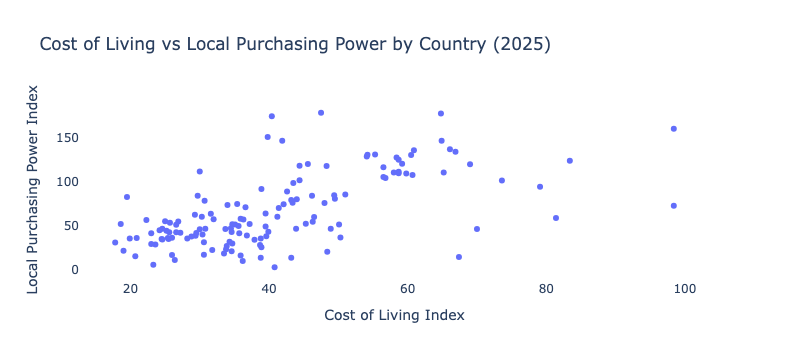

In [16]:
# 8.5 Cost of living vs purchasing power scatter — 2025
fig = px.scatter(
    latest,
    x='Cost of Living Index',
    y='Local Purchasing Power Index',
    hover_name='Country',
    title='Cost of Living vs Local Purchasing Power by Country (2025)',
    labels={
        'Cost of Living Index': 'Cost of Living Index',
        'Local Purchasing Power Index': 'Local Purchasing Power Index'
    }
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

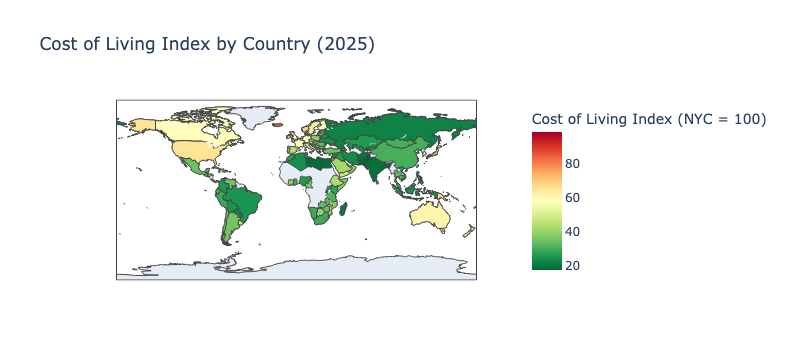

In [17]:
# 8.6 Choropleth map of cost of living by country (2025)
fig = px.choropleth(
    latest,
    locations='Country',
    locationmode='country names',
    color='Cost of Living Index',
    color_continuous_scale='RdYlGn_r',
    title='Cost of Living Index by Country (2025)',
    labels={'Cost of Living Index': 'Cost of Living Index (NYC = 100)'}
)
fig.show()

In [18]:
# 8.7 Rank shifts since COVID: which countries became relatively more or less expensive?
# Using consistent countries only for a fair comparison
pre  = df_consistent[df_consistent['year'] == 2019][['Country', 'cost_rank']].rename(columns={'cost_rank': 'rank_2019'})
post = df_consistent[df_consistent['year'] == 2025][['Country', 'cost_rank']].rename(columns={'cost_rank': 'rank_2025'})

rank_shift = pd.merge(pre, post, on='Country')
# Positive rank_change = moved up (became relatively more expensive)
# Negative rank_change = moved down (became relatively cheaper)
rank_shift['rank_change'] = rank_shift['rank_2019'] - rank_shift['rank_2025']

print('Countries that became relatively MORE expensive since COVID:')
print(rank_shift.sort_values('rank_change', ascending=False).head(10).to_string(index=False))

print('\nCountries that became relatively CHEAPER since COVID:')
print(rank_shift.sort_values('rank_change').head(10).to_string(index=False))

Countries that became relatively MORE expensive since COVID:
   Country  rank_2019  rank_2025  rank_change
   Armenia         98         63           35
   Albania         84         61           23
 Singapore         21          5           16
 Argentina         95         79           16
Costa Rica         48         33           15
 Sri Lanka        106         93           13
 Lithuania         61         48           13
   Estonia         47         35           12
    Poland         78         66           12
    Serbia         89         77           12

Countries that became relatively CHEAPER since COVID:
  Country  rank_2019  rank_2025  rank_change
    Ghana         46         99          -53
   Brazil         67        119          -52
   Russia         88        132          -44
     Iran         86        128          -42
 Zimbabwe         43         83          -40
Indonesia         84        124          -40
Mauritius         40         80          -40
    Japan         

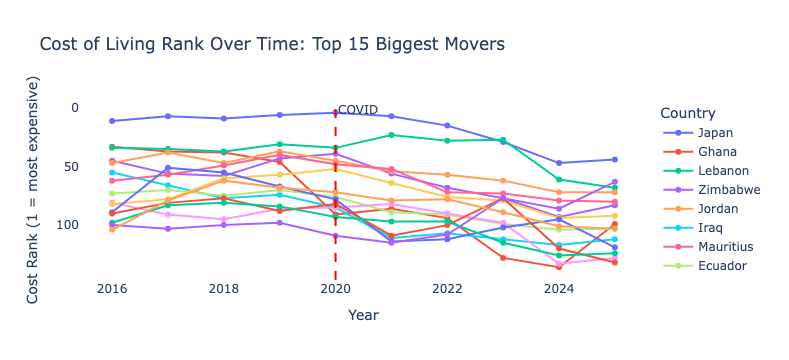

In [19]:
# 8.8 Visualise rank shifts for top movers
top_movers = rank_shift.reindex(
    rank_shift['rank_change'].abs().nlargest(15).index
)['Country'].tolist()

trend = df_consistent[df_consistent['Country'].isin(top_movers)]

fig = px.line(
    trend,
    x='year',
    y='cost_rank',
    color='Country',
    title='Cost of Living Rank Over Time: Top 15 Biggest Movers',
    markers=True,
    labels={'cost_rank': 'Cost Rank (1 = most expensive)', 'year': 'Year'}
)
fig.add_vline(x=2020, line_dash='dash', line_color='red', annotation_text='COVID')
fig.update_yaxes(autorange='reversed')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()